# DETECTION DE FAUX BILLETS
## par Mathieu TENE

--- 
## Table des matières

1. [I. Exploration et Nettoyage](#section1)
2. [II. Préparation des données](#section2)
3. [III. Modélisation](#section3)
4. [IV. Modèle Final et Préparation au Déploiement](#section4)

---

# I. EXPLORATION ET NETTOYAGE

## I.1 Verifications et corrections

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Chargement du dataset
df = pd.read_csv("billets.csv", sep=";")

# Affichage de quelques lignes pour comprendre la structure
print(df.head(10))
print("\n" + "="*100 + "\n")
print(df.tail(10))

   Unnamed: 0  diagonal  height_left  height_right  margin_low  margin_up  \
0        True    171.81       104.86        104.95        4.52       2.89   
1        True    171.46       103.36        103.66        3.77       2.99   
2        True    172.69       104.48        103.50        4.40       2.94   
3        True    171.36       103.91        103.94        3.62       3.01   
4        True    171.73       104.28        103.46        4.04       3.48   
5        True    172.17       103.74        104.08        4.42       2.95   
6        True    172.34       104.18        103.85        4.58       3.26   
7        True    171.88       103.76        104.08        3.98       2.92   
8        True    172.47       103.92        103.67        4.00       3.25   
9        True    172.47       104.07        104.02        4.04       3.25   

   length  
0  112.83  
1  113.09  
2  113.16  
3  113.51  
4  112.54  
5  112.81  
6  112.81  
7  113.08  
8  112.85  
9  113.45  


      Unnamed: 0  

In [2]:
# Renommer la colonne sans nom
df.rename(columns={'Unnamed: 0': 'is_genuine'}, inplace=True)

# Verifications des types des colonnes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   is_genuine    1500 non-null   bool   
 1   diagonal      1500 non-null   float64
 2   height_left   1500 non-null   float64
 3   height_right  1500 non-null   float64
 4   margin_low    1463 non-null   float64
 5   margin_up     1500 non-null   float64
 6   length        1500 non-null   float64
dtypes: bool(1), float64(6)
memory usage: 71.9 KB


## I.2 Exploration des donnees

### Statistique descriptive

In [3]:
df.describe()

,diagonal,height_left,height_right,margin_low,margin_up,length
count,1500.000000,1500.000000,1500.000000,1463.000000,1500.000000,1500.00000
mean,171.958440,104.029533,103.920307,4.485967,3.151473,112.67850
std,0.305195,0.299462,0.325627,0.663813,0.231813,0.87273
min,171.040000,103.140000,102.820000,2.980000,2.270000,109.49000
25%,171.750000,103.820000,103.710000,4.015000,2.990000,112.03000
50%,171.960000,104.040000,103.920000,4.310000,3.140000,112.96000
75%,172.170000,104.230000,104.150000,4.870000,3.310000,113.34000
max,173.010000,104.880000,104.950000,6.900000,3.910000,114.44000


### Repartition de la variable cle (is_genuine)

In [4]:
print(df['is_genuine'].value_counts())
print(f"\nProportion : \n{df['is_genuine'].value_counts(normalize=True)}")

is_genuine
True     1000
False     500
Name: count, dtype: int64

Proportion : 
is_genuine
True     0.666667
False    0.333333
Name: proportion, dtype: float64


> Le repartitions des classes est equilibree (les proportions sont > 10%). Par consequent le split train/test n'aura pas besoin de technique specifique.

### Valeurs manquantes

In [5]:
print("Nombre de valeurs manquantes :")
print(df.isnull().sum())
print(f"\nPourcentage :")
print(df.isnull().sum() * 100 / len(df))

Nombre de valeurs manquantes :
is_genuine       0
diagonal         0
height_left      0
height_right     0
margin_low      37
margin_up        0
length           0
dtype: int64

Pourcentage :
is_genuine      0.000000
diagonal        0.000000
height_left     0.000000
height_right    0.000000
margin_low      2.466667
margin_up       0.000000
length          0.000000
dtype: float64


> Il en a 37 pour la variable *margin_low*. Elles seront traitees selon l'analyse des visualisations.

## I.3 Visualisation

In [6]:
plt.style.use('default')
sns.set_palette("husl")

### Distributions des variables

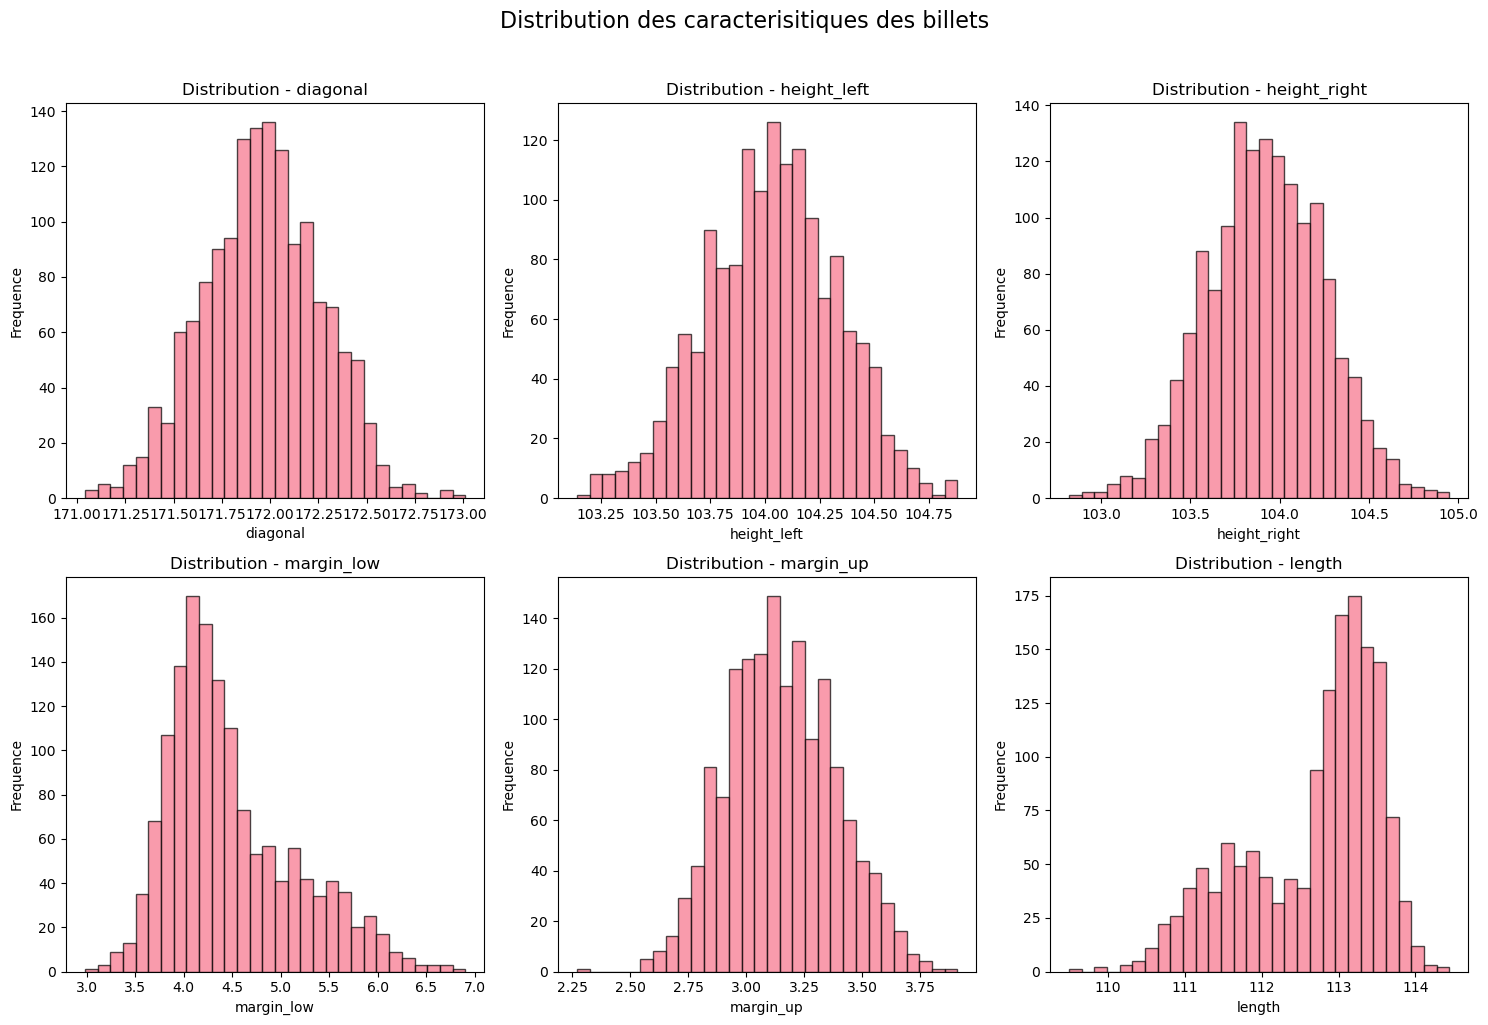

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Distribution des caracterisitiques des billets', fontsize=16, y=1.02)

features = ['diagonal', 'height_left', 'height_right', 'margin_low', 'margin_up', 'length']

for idx, feature in enumerate(features):
    row = idx//3
    col = idx%3

    # Histogramme avec KDE
    axes[row, col].hist(df[feature].dropna(), bins=30, alpha=0.7, edgecolor='black')
    axes[row, col].set_title(f'Distribution - {feature}')
    axes[row, col].set_xlabel(feature)
    axes[row, col].set_ylabel('Frequence')

plt.tight_layout()
plt.show()

> Toutes les variables suivent approximativement une distribution normale
* *diagonal* : centré autour de 172, distribution bien symétrique
* *height_left* et *height_right* : très similaires (~104), confirme qu'elles mesurent la même dimension
* *margin_low* : distribution plus étalée (3.5 à 6.5), présence de quelques valeurs extrêmes
* *margin_up* : distribution concentrée autour de 3.0-3.5
* *length* : bimodale légère (deux pics : ~112 et ~113), pourrait correspondre à deux types de billets

### Distribution par classe (vrai vs faux billets)

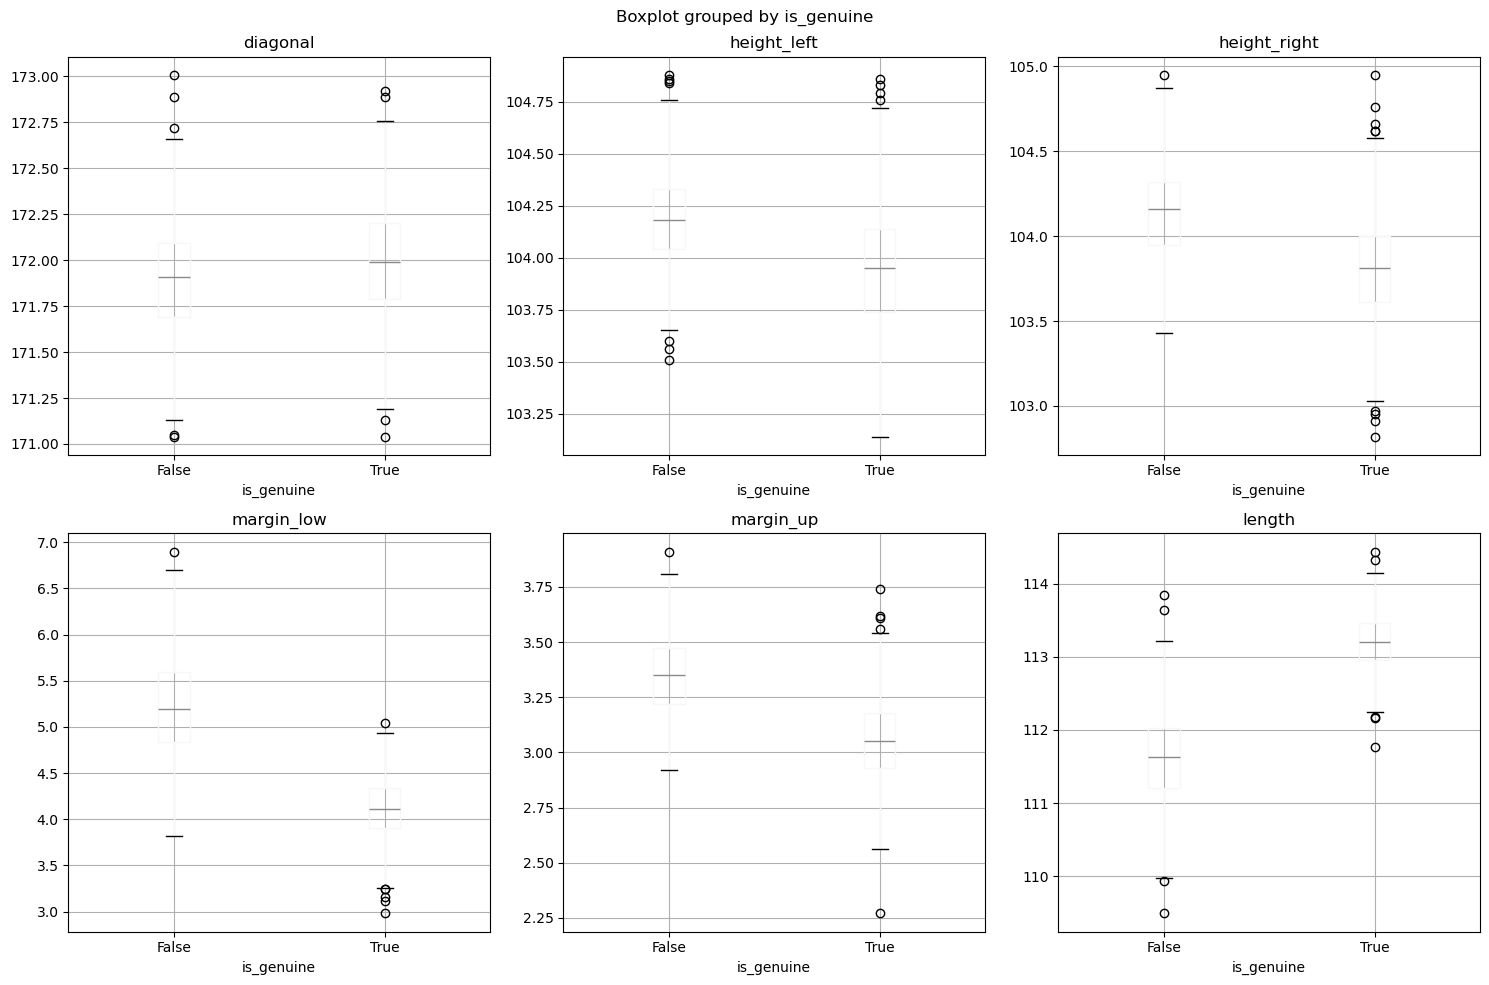

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Distribution par classe (Vrai vs Faux)', fontsize=16, y=1.02)

for idx, feature in enumerate(features):
    row = idx//3
    col = idx%3

    # Boxplot par classe
    df.boxplot(column=feature, by='is_genuine', ax=axes[row, col])
    axes[row, col].set_title(f'{feature}')
    axes[row, col].set_xlabel('is_genuine')

plt.tight_layout()
plt.show()

> Features les plus discriminantes :
* *diagonal* (**Tres bon**) : forte séparation. False ~171, True ~172.5
* *height_left* (**Excellent**) : très forte séparation. False ~103.6, True ~104.3
* *height_right* (**Tres bon**) : forte séparation, False ~103.9, True ~104.2
* *margin_low* (**Bon**) : séparation visible, False ~5.0, True ~3.8
* *margin_up* (**Moyen**) : Légère séparation, False ~3.5, True ~3.0
* *length* (**Bon**) : Faible chevauchement, False ~113.5, True ~112.5

### Matrice de correlation

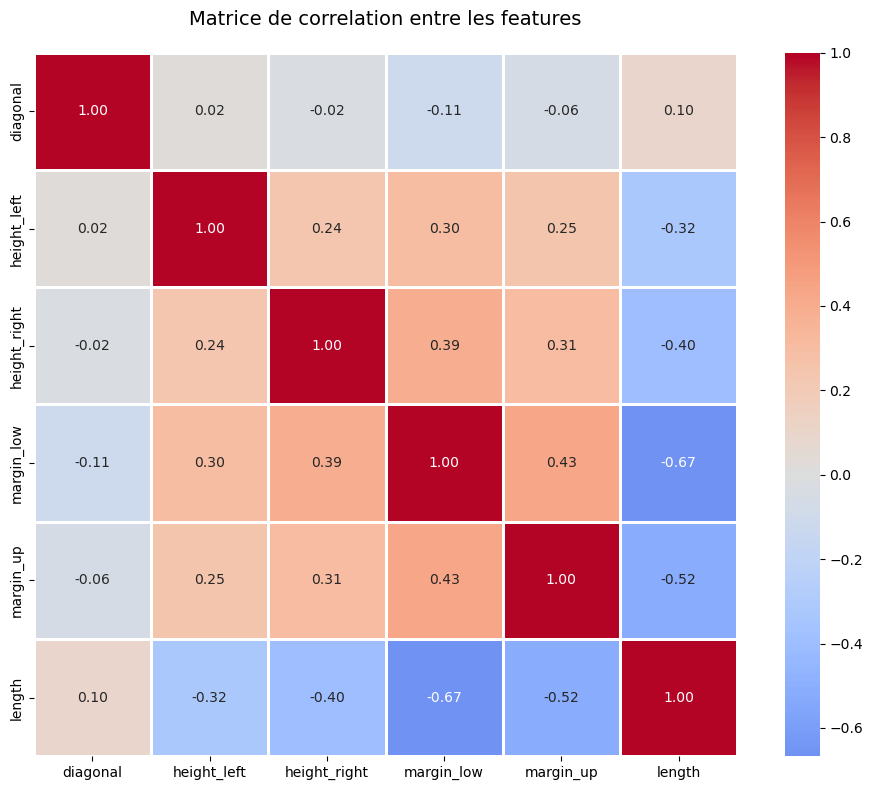

In [9]:
plt.figure(figsize=(10, 8))
cor_matrix = df[features].corr()
sns.heatmap(cor_matrix, annot=True, cmap='coolwarm', center=0, square=True, linewidths=1, fmt='.2f')
plt.title('Matrice de correlation entre les features', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

* *margin_low* et *margin_up* : corrélation négative logique (si marge basse augmente, marge haute diminue)
* *margin_low* et *length* : corrélation négative forte (-0.67)
* *diagonal* : presque indépendante des autres variables (corrélations < 0.11) → très bonne feature !

Pas de multicolinéarité critique (aucune corrélation > 0.8), donc on peut garder toutes les features.

# II. PRÉPARATION DES DONNÉES

### Gestion des valeurs manquantes

Une imputation par classe des valeurs manquantes permettrait de restpecteur la distributions avec une meilleure precision que la mediande globale.

In [10]:
print("Avant imputation :")
print(df['margin_low'].isnull().sum())

# Imputation par classe
df['margin_low'] = df.groupby('is_genuine')['margin_low'].transform(
    lambda x: x.fillna(x.median())
)

print("\nAprès imputation :")
print(df['margin_low'].isnull().sum())

Avant imputation :
37

Après imputation :
0


### Separtion des Features / Target

In [11]:
# Features
X = df.drop('is_genuine', axis=1)

# Target
Y = df['is_genuine']

print(f"X (features) : {X.columns}")
print(f"Y (target) : {Y.name}")

X (features) : Index(['diagonal', 'height_left', 'height_right', 'margin_low', 'margin_up',
       'length'],
      dtype='object')
Y (target) : is_genuine


### Split train/test

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

### Standardisation des donnees

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

X_train_scaled.describe()

,diagonal,height_left,height_right,margin_low,margin_up,length
count,1.200000e+03,1.200000e+03,1.200000e+03,1.200000e+03,1.200000e+03,1.200000e+03
mean,5.147882e-14,-1.034358e-14,2.454333e-15,1.110223e-16,1.006602e-16,-1.441662e-14
std,1.000417e+00,1.000417e+00,1.000417e+00,1.000417e+00,1.000417e+00,1.000417e+00
min,-3.065540e+00,-2.973514e+00,-3.133224e+00,-2.096162e+00,-3.820061e+00,-3.647688e+00
25%,-6.651824e-01,-7.055866e-01,-6.569296e-01,-6.855086e-01,-7.012019e-01,-7.437474e-01
50%,1.583569e-03,2.815454e-02,2.898067e-03,-2.715125e-01,-5.143952e-02,3.294480e-01
75%,6.683496e-01,6.618401e-01,7.170645e-01,6.024794e-01,6.849578e-01,7.483960e-01
max,3.502105e+00,2.829712e+00,3.201122e+00,3.699784e+00,3.284007e+00,2.033935e+00


# III. MODÉLISATION

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

## 1. Baseline

In [17]:
# Modeèle
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, Y_train)

# Prédictions
Y_pred_log = log_reg.predict(X_test_scaled)

# Métriques
acc_log = accuracy_score(Y_test, Y_pred_log)
prec_log = precision_score(Y_test, Y_pred_log)
rec_log = recall_score(Y_test, Y_pred_log)
f1_log = f1_score(Y_test, Y_pred_log)

print(f"\nAccuracy : {acc_log:.4f}")
print(f"Precision : {prec_log:.4f}")
print(f"Recall : {rec_log:.4f}")
print(f"F1-Score : {f1_log:.4f}")

print("\nMatrice de confusion :")
print(confusion_matrix(Y_test, Y_pred_log))

print("\nRapport de classification :")
print(classification_report(Y_test, Y_pred_log))


Accuracy : 0.9933
Precision : 0.9950
Recall : 0.9950
F1-Score : 0.9950

Matrice de confusion :
[[ 99   1]
 [  1 199]]

Rapport de classification :
              precision    recall  f1-score   support

       False       0.99      0.99      0.99       100
        True       0.99      0.99      0.99       200

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300



## 2. KNN

In [20]:
# Test avec k=5 voisins
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, Y_train)

Y_pred_knn = knn.predict(X_test_scaled)

acc_knn = accuracy_score(Y_test, Y_pred_knn)
prec_knn = precision_score(Y_test, Y_pred_knn)
rec_knn = recall_score(Y_test, Y_pred_knn)
f1_knn = f1_score(Y_test, Y_pred_knn)

print(f"\nAccuracy : {acc_knn:.4f}")
print(f"Precision : {prec_knn:.4f}")
print(f"Recall : {rec_knn:.4f}")
print(f"F1-Score : {f1_knn:.4f}")

print("\nMatrice de confusion :")
print(confusion_matrix(Y_test, Y_pred_knn))


Accuracy : 0.9833
Precision : 0.9851
Recall : 0.9900
F1-Score : 0.9875

Matrice de confusion :
[[ 97   3]
 [  2 198]]


## 3. Arbre de décision

In [21]:
dt = DecisionTreeClassifier(random_state=42, max_depth=10)
dt.fit(X_train, Y_train)  # Pas besoin de standardisation pour les arbres

Y_pred_dt = dt.predict(X_test)

acc_dt = accuracy_score(Y_test, Y_pred_dt)
prec_dt = precision_score(Y_test, Y_pred_dt)
rec_dt = recall_score(Y_test, Y_pred_dt)
f1_dt = f1_score(Y_test, Y_pred_dt)

print(f"\nAccuracy : {acc_dt:.4f}")
print(f"Precision : {prec_dt:.4f}")
print(f"Recall : {rec_dt:.4f}")
print(f"F1-Score : {f1_dt:.4f}")

print("\nMatrice de confusion :")
print(confusion_matrix(Y_test, Y_pred_dt))


Accuracy : 0.9833
Precision : 0.9899
Recall : 0.9850
F1-Score : 0.9875

Matrice de confusion :
[[ 98   2]
 [  3 197]]


## 4. Random Forest

In [22]:
# Ensemble d'arbres pour réduire l'overfitting
rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf.fit(X_train, Y_train)

Y_pred_rf = rf.predict(X_test)

acc_rf = accuracy_score(Y_test, Y_pred_rf)
prec_rf = precision_score(Y_test, Y_pred_rf)
rec_rf = recall_score(Y_test, Y_pred_rf)
f1_rf = f1_score(Y_test, Y_pred_rf)

print(f"\nAccuracy : {acc_rf:.4f}")
print(f"Precision : {prec_rf:.4f}")
print(f"Recall : {rec_rf:.4f}")
print(f"F1-Score : {f1_rf:.4f}")

print("\nMatrice de confusion :")
print(confusion_matrix(Y_test, Y_pred_rf))


Accuracy : 0.9900
Precision : 0.9900
Recall : 0.9950
F1-Score : 0.9925

Matrice de confusion :
[[ 98   2]
 [  1 199]]


## 5. Bagging

In [23]:
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=10),
    n_estimators=50,
    random_state=42
)
bagging.fit(X_train, Y_train)

Y_pred_bag = bagging.predict(X_test)

acc_bag = accuracy_score(Y_test, Y_pred_bag)
prec_bag = precision_score(Y_test, Y_pred_bag)
rec_bag = recall_score(Y_test, Y_pred_bag)
f1_bag = f1_score(Y_test, Y_pred_bag)

print(f"\nAccuracy : {acc_bag:.4f}")
print(f"Precision : {prec_bag:.4f}")
print(f"Recall : {rec_bag:.4f}")
print(f"F1-Score : {f1_bag:.4f}")

print("\nMatrice de confusion :")
print(confusion_matrix(Y_test, Y_pred_bag))


Accuracy : 0.9833
Precision : 0.9899
Recall : 0.9850
F1-Score : 0.9875

Matrice de confusion :
[[ 98   2]
 [  3 197]]


## 6. Adaboost

In [24]:
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=3),
    n_estimators=50,
    random_state=42
)
ada.fit(X_train, Y_train)

Y_pred_ada = ada.predict(X_test)

acc_ada = accuracy_score(Y_test, Y_pred_ada)
prec_ada = precision_score(Y_test, Y_pred_ada)
rec_ada = recall_score(Y_test, Y_pred_ada)
f1_ada = f1_score(Y_test, Y_pred_ada)

print(f"\nAccuracy : {acc_ada:.4f}")
print(f"Precision : {prec_ada:.4f}")
print(f"Recall : {rec_ada:.4f}")
print(f"F1-Score : {f1_ada:.4f}")

print("\nMatrice de confusion :")
print(confusion_matrix(Y_test, Y_pred_ada))


Accuracy : 0.9867
Precision : 0.9900
Recall : 0.9900
F1-Score : 0.9900

Matrice de confusion :
[[ 98   2]
 [  2 198]]


## 7. Gradient Boosting

In [25]:
gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)
gb.fit(X_train, Y_train)

Y_pred_gb = gb.predict(X_test)

acc_gb = accuracy_score(Y_test, Y_pred_gb)
prec_gb = precision_score(Y_test, Y_pred_gb)
rec_gb = recall_score(Y_test, Y_pred_gb)
f1_gb = f1_score(Y_test, Y_pred_gb)

print(f"\nAccuracy : {acc_gb:.4f}")
print(f"Precision : {prec_gb:.4f}")
print(f"Recall : {rec_gb:.4f}")
print(f"F1-Score : {f1_gb:.4f}")

print("\nMatrice de confusion :")
print(confusion_matrix(Y_test, Y_pred_gb))


Accuracy : 0.9800
Precision : 0.9850
Recall : 0.9850
F1-Score : 0.9850

Matrice de confusion :
[[ 97   3]
 [  3 197]]


## 8. Comparaison des modèles

In [26]:
results = pd.DataFrame({
    'Modèle': ['Logistic Regression', 'KNN', 'Decision Tree', 'Random Forest', 
               'Bagging', 'AdaBoost', 'Gradient Boosting'],
    'Accuracy': [acc_log, acc_knn, acc_dt, acc_rf, acc_bag, acc_ada, acc_gb],
    'Precision': [prec_log, prec_knn, prec_dt, prec_rf, prec_bag, prec_ada, prec_gb],
    'Recall': [rec_log, rec_knn, rec_dt, rec_rf, rec_bag, rec_ada, rec_gb],
    'F1-Score': [f1_log, f1_knn, f1_dt, f1_rf, f1_bag, f1_ada, f1_gb]
})

print("\n", results.to_string(index=False))

# Trier par F1-Score
results_sorted = results.sort_values('F1-Score', ascending=False)
print("\n\nClassement par F1-Score :")
print(results_sorted.to_string(index=False))


              Modèle  Accuracy  Precision  Recall  F1-Score
Logistic Regression  0.993333   0.995000   0.995  0.995000
                KNN  0.983333   0.985075   0.990  0.987531
      Decision Tree  0.983333   0.989950   0.985  0.987469
      Random Forest  0.990000   0.990050   0.995  0.992519
            Bagging  0.983333   0.989950   0.985  0.987469
           AdaBoost  0.986667   0.990000   0.990  0.990000
  Gradient Boosting  0.980000   0.985000   0.985  0.985000


Classement par F1-Score :
             Modèle  Accuracy  Precision  Recall  F1-Score
Logistic Regression  0.993333   0.995000   0.995  0.995000
      Random Forest  0.990000   0.990050   0.995  0.992519
           AdaBoost  0.986667   0.990000   0.990  0.990000
                KNN  0.983333   0.985075   0.990  0.987531
      Decision Tree  0.983333   0.989950   0.985  0.987469
            Bagging  0.983333   0.989950   0.985  0.987469
  Gradient Boosting  0.980000   0.985000   0.985  0.985000


### Visualisation des performances

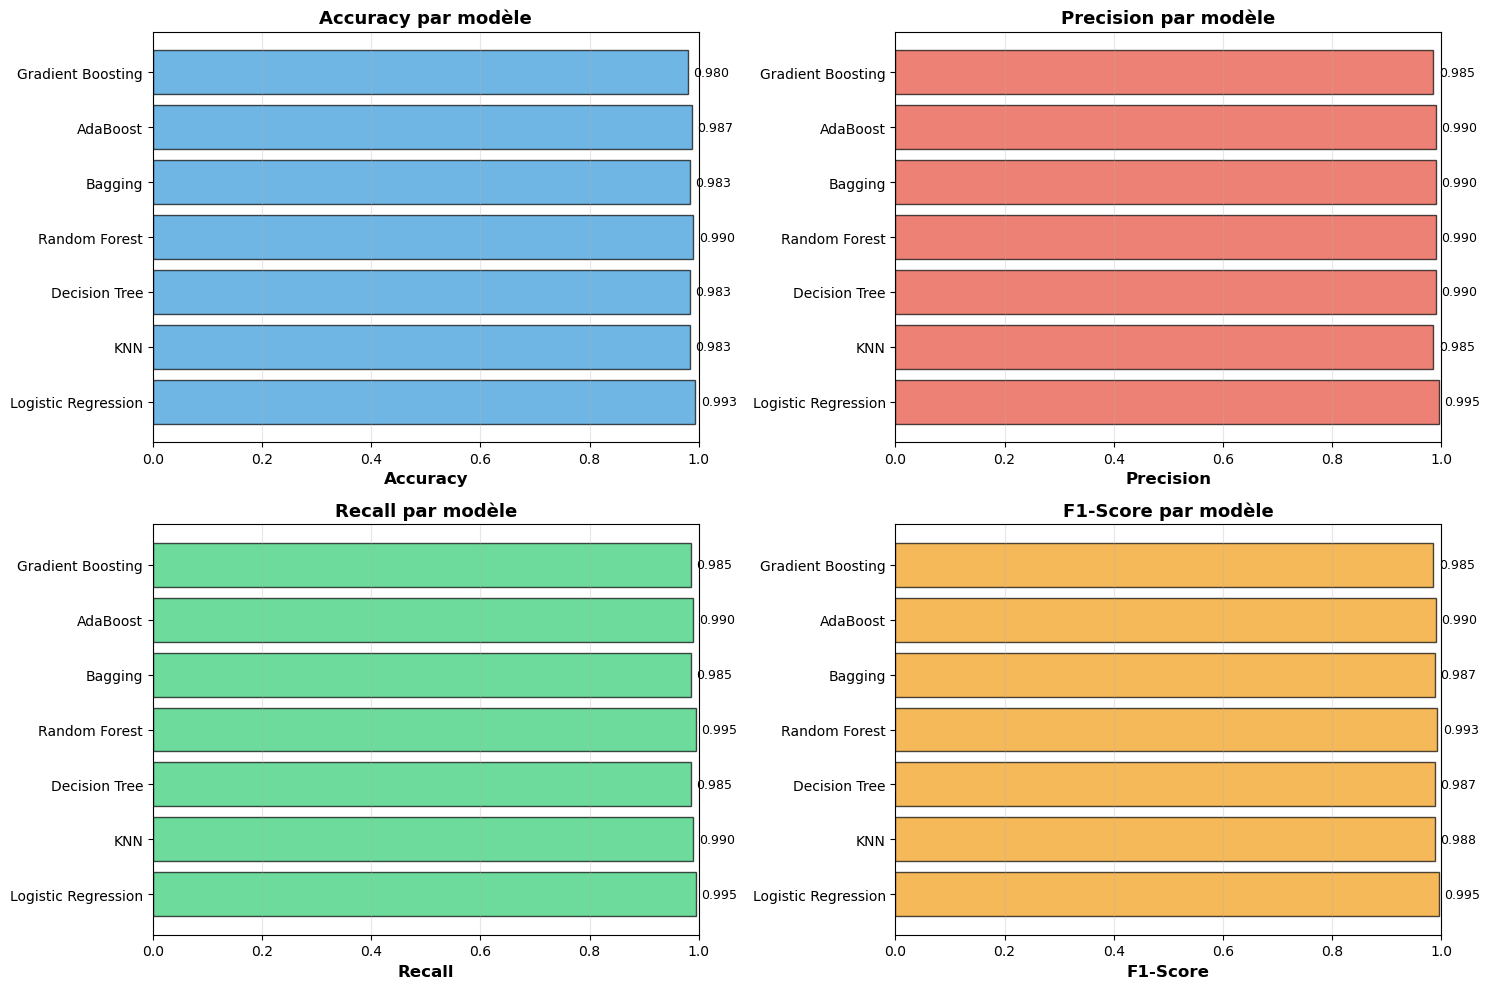

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

for idx, metric in enumerate(metrics):
    row = idx // 2
    col = idx % 2
    
    axes[row, col].barh(results['Modèle'], results[metric], color=colors[idx], alpha=0.7, edgecolor='black')
    axes[row, col].set_xlabel(metric, fontsize=12, weight='bold')
    axes[row, col].set_xlim([0, 1])
    axes[row, col].set_title(f'{metric} par modèle', fontsize=13, weight='bold')
    axes[row, col].grid(axis='x', alpha=0.3)
    
    # Ajouter les valeurs sur les barres
    for i, v in enumerate(results[metric]):
        axes[row, col].text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

### Interprétation par métrique

#### Précision (~99%)
- Sur 300 billets du test, seulement 2-3 erreurs

#### Précision (~99%)
- Quand le modèle dit "vrai billet", il a une raison à 99% du temps
- Très peu de faux positifs (vrais billets rejetés par erreur)

#### Rappel (~99%)
- Sur 100 faux billets, le modèle en détecte 99
- Très peu de faux négatifs (faux billets acceptés par erreur)

#### Score F1 (0,995 pour la régression logistique)
- Excellent équilibre entre précision et rappel
- Les modèles n'ont pas de faiblesse particulière

### Sauvegarde des résultats

In [28]:
results.to_csv('model_comparison.csv', index=False)

# IV. <a id='section4'></a>MODÈLE FINAL ET PRÉPARATION AU DÉPLOIEMENT

### IV.1 Choix du Random Forest

Bien que la régression logistique offre d'excellentes performances, nous avons choisi d'implémenter un **Random Forest** pour le déploiement final. 

Ce choix se justifie par une meilleure robustesse face aux données aberrantes (extrapolation) et une stabilité accrue en conditions réelles.

In [ ]:
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

# Entraînement final
features = ['diagonal', 'height_left', 'height_right', 'margin_low', 'margin_up', 'length']
X_final = df[features]
y_final = df['is_genuine']

scaler_final = StandardScaler()
X_scaled = scaler_final.fit_transform(X_final)

model_final = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
model_final.fit(X_scaled, y_final)

# Sauvegarde
joblib.dump(model_final, 'model.joblib')
joblib.dump(scaler_final, 'scaler.joblib')
print('Modèle et Scaler sauvegardés pour le déploiement.')

### IV.2 Application Dash

L'étape finale a été le développement d'une application web interactive permettant de tester des billets en temps réel avec un système de contrôle de cohérence des données.